[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ee-ortiz/ISIS-4825_202510_IMAGENES_Y_VISION/blob/main/Laboratorio_08/MISIS4825_Laboratorio08_Taller.ipynb)

![image](https://drive.google.com/u/0/uc?id=15DUc09hFGqR8qcpYiN1OajRNaASmiL6d&export=download)

# Laboratorio 08 – Taller: Redes Neuronales Convolucionales con Modelos Fundacionales

## Introducción

En este taller abordaremos el tema de las redes neuronales convolucionales (CNN) y la aplicación de **modelos fundacionales** mediante *transfer learning*. Para ello, utilizaremos el conjunto de datos **drone-bird classification** de Kaggle.

El objetivo es comparar el rendimiento de un modelo CNN entrenado desde cero con el de un modelo fundacional (por ejemplo, VGG16) adaptado a nuestra tarea de **clasificación de Drones y aves**.

## Objetivos

1. **Entrenar un modelo CNN desde cero** utilizando Keras y TensorFlow.
2. **Aplicar transfer learning** con un modelo fundacional, aprovechando características previamente aprendidas en conjuntos de datos masivos.
3. **Comparar** el rendimiento y la eficiencia de ambos enfoques.
4. **Experimentar** con distintos modelos fundacionales y diferentes configuraciones de hiperparámetros.


**Datos:** [drone-bird classification](https://www.kaggle.com/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images)

## 1. Descarga y Preparación del Dataset de Kaggle

In [1]:
import os
import json

In [2]:
# Instalación de Kaggle
%pip install kaggle --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cargar credenciales desde kaggle.json
with open('kaggle.json', 'r') as f:
    kaggle_creds = json.load(f)
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

# Descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('imbikramsaha/drone-bird-classification', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/imbikramsaha/drone-bird-classification


## 2. Exploración de Datos

Vamos a inspeccionar la carpeta que contiene las imágenes de drones y aves y crear un DataFrame con la ruta de cada imagen y su etiqueta. Luego, mostraremos cada una de las categorías y un breve conteo de cuántas imágenes hay por categoría.

Total de imágenes: 324

Número de imágenes por categoría:
label
birds     164
drones    160
Name: count, dtype: int64


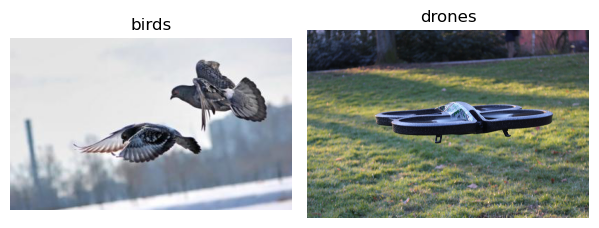

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directorio base que contiene las carpetas 'train' y 'test'
base_dir = 'data/drone_or_bird'

filepaths = []
labels = []

# Recorrer las carpetas 'train' y 'test'
for label in os.listdir(base_dir):
    label_path = os.path.join(base_dir, label)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            ext = os.path.splitext(file)[1].lower()
            if ext in ['.png', '.jpg', '.jpeg']:
                filepaths.append(os.path.join(label_path, file))
                labels.append(label)

# Crear DataFrame con las rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Mostrar conteo total y por categoría
print("Total de imágenes:", len(data_df))
print("\nNúmero de imágenes por categoría:")
print(data_df['label'].value_counts())

# Mostrar una imagen por categoría
categorias = data_df['label'].unique()
num_muestras = len(categorias)

plt.figure(figsize=(15, 10))
for i, categoria in enumerate(categorias[:num_muestras]):
    img_path = data_df[data_df['label'] == categoria].iloc[0]['filepath']
    img = mpimg.imread(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{categoria}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

Dividimos el dataset completo en tres conjuntos:
- **Entrenamiento (70%)**
- **Validación (20%)**
- **Prueba (10%)**

Esta separación nos permitirá evaluar la capacidad de generalización de nuestros modelos.

In [5]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en 70% entrenamiento y 30% (validación + prueba)
train_df, test_val_df = train_test_split(
    data_df, test_size=0.3, random_state=42, stratify=data_df['label']
)

# A partir del 30% restante, dividir en 2/3 para validación y 1/3 para prueba (~20% y ~10% del total, respectivamente)
val_df, test_df = train_test_split(
    test_val_df, test_size=(1/3), random_state=42, stratify=test_val_df['label']
)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))


Entrenamiento: 226
Validación: 65
Prueba: 33


## 4. Generadores de Imágenes

Utilizaremos la clase `ImageDataGenerator` de Keras para:
- Reescalar los valores de píxel al rango [0, 1].
- Aplicar data augmentation (rotación, volteo horizontal) en el conjunto de entrenamiento.
- Mantener intactos los conjuntos de validación y prueba (solo reescalado).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

img_size = (128, 128)  # Compatible con la mayoría de modelos fundacionales
batch_size = 32

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# Diccionario con nombre de clase -> índice
labels_map = train_gen.class_indices

# Invertimos el diccionario para tener índice -> nombre de clase
idx_to_class = {v: k for k, v in labels_map.items()}

print("\nCategorías reconocidas:")
for idx in sorted(idx_to_class):
    print(f"  Clase {idx}: '{idx_to_class[idx]}'")

num_classes = len(labels_map)
print("Número de clases:", num_classes)

Found 226 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.
Found 33 validated image filenames belonging to 2 classes.

Categorías reconocidas:
  Clase 0: 'birds'
  Clase 1: 'drones'
Número de clases: 2


## 5. Construcción del Modelo de Red Convolucional

En esta sección, definiremos una CNN desde cero (modelo *scratch*) para la clasificación de fracturas. Este modelo tendrá varias capas convolucionales y capas de pooling, seguido de capas densas para la clasificación.


In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_scratch = Sequential([
    # Primer bloque convolucional
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Segundo bloque
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Tercer bloque
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Aplanamiento y capas densas
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_scratch.summary()

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,538,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,677,986 (21.66 MB)

 Trainable params: 5,677,986 (21.66 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Definición de Callbacks

Utilizamos *ModelCheckpoint* para guardar la mejor versión del modelo, *EarlyStopping* para detener el entrenamiento cuando la métrica de validación deje de mejorar y *ReduceLROnPlateau* para ajustar dinámicamente la tasa de aprendizaje.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_scratch = [
    ModelCheckpoint('best_model_scratch.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

## 7. Entrenamiento del Modelo

Entrenamos la red desde cero con los parámetros definidos anteriormente.  

In [9]:
import tensorflow as tf

epochs_scratch = 15
with tf.device('/device:GPU:0'):
    history_scratch = model_scratch.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_scratch,
        callbacks=callbacks_scratch
    )

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5030 - loss: 0.7897 - val_accuracy: 0.4923 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 983ms/step - accuracy: 0.5362 - loss: 0.6928 - val_accuracy: 0.4923 - val_loss: 0.6884 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5361 - loss: 0.6870 - val_accuracy: 0.5846 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 989ms/step - accuracy: 0.5757 - loss: 0.6926 - val_accuracy: 0.5231 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4580 - loss: 0.6918 - val_accuracy: 0.5077 - val_loss: 0.6863 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4660 - loss: 0.6917 - val_accuracy: 0.6000 - val_loss: 0.6766 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5826 - loss: 0.6887 - val_accuracy: 0.4923 - val_l

## 8. Evaluación del Modelo

Visualizaremos las curvas de entrenamiento (precisión y pérdida) y cargaremos la mejor versión del modelo para evaluar en el conjunto de prueba.

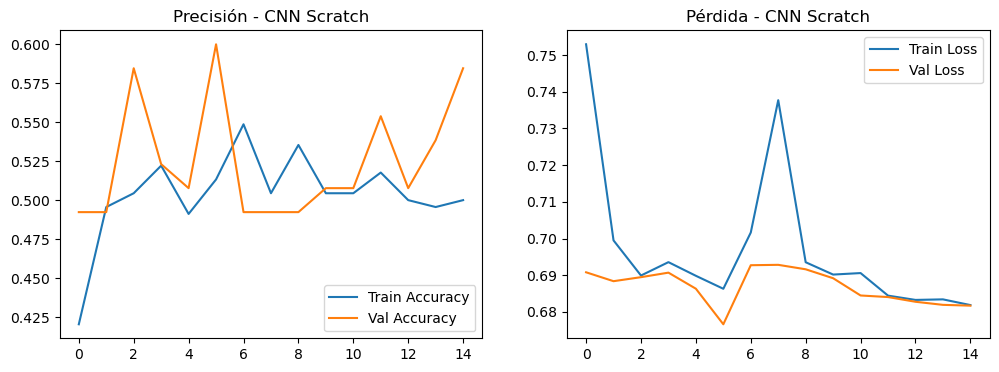

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


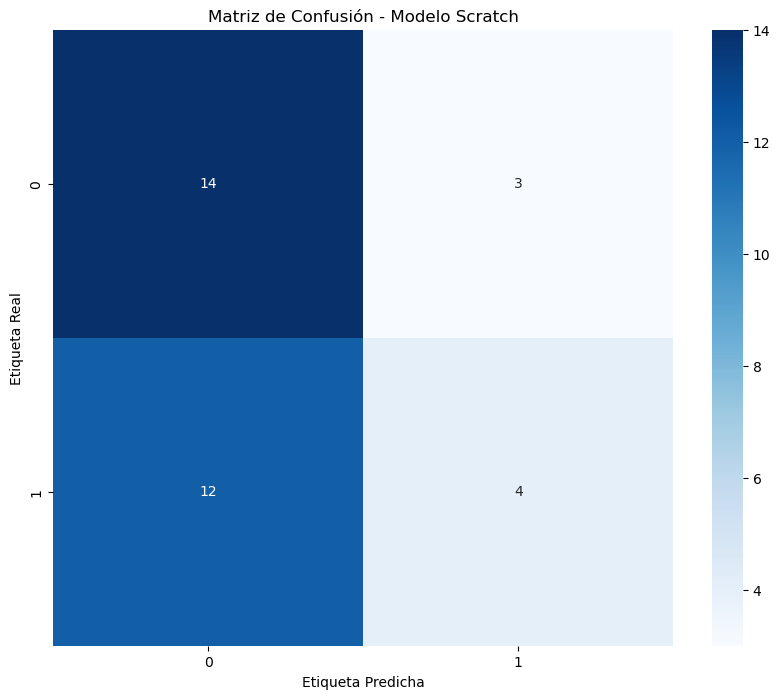

Reporte de Clasificación - Modelo Scratch

              precision    recall  f1-score   support

       birds       0.54      0.82      0.65        17
      drones       0.57      0.25      0.35        16

    accuracy                           0.55        33
   macro avg       0.55      0.54      0.50        33
weighted avg       0.55      0.55      0.50        33



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc = history_scratch.history['accuracy']
val_acc = history_scratch.history['val_accuracy']
loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Precisión - CNN Scratch')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Pérdida - CNN Scratch')
plt.show()

# Cargar el mejor modelo y evaluar
best_scratch_model = load_model('best_model_scratch.keras')
test_gen.reset()
preds_scratch = best_scratch_model.predict(test_gen, verbose=1)
y_pred_scratch = np.argmax(preds_scratch, axis=1)
y_true = test_gen.classes

cm_scratch = confusion_matrix(y_true, y_pred_scratch)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Modelo Scratch')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Modelo Scratch")
print()
print(classification_report(y_true, y_pred_scratch, target_names=labels_map, zero_division=0))

## 9. Transfer Learning con Modelos Fundacionales

En esta sección se aprovechará el poder de un modelo pre-entrenado, en concreto **VGG16**, para aplicar *transfer learning* en nuestra tarea de clasificación de imágenes. Utilizar un modelo como VGG16 permite:
  
- **Reducción en el tiempo de entrenamiento:** El modelo base ya ha sido entrenado en un conjunto masivo (ImageNet), lo que significa que las capas iniciales han aprendido a extraer características generales muy útiles.
- **Mejor rendimiento en datasets limitados:** Al reutilizar las representaciones aprendidas, se pueden obtener resultados competitivos incluso cuando el conjunto de datos de destino es relativamente pequeño.
  
### Sobre VGG16

VGG16 fue desarrollado por Simonyan y Zisserman en su artículo *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* ([ver paper](https://arxiv.org/abs/1409.1556)). Algunas de sus características destacadas son:

- **Filtros uniformes:** Emplea filtros uniformes de 3x3 a lo largo de toda la arquitectura, lo que facilita la extracción sistemática de patrones jerárquicos a distintos niveles de abstracción.
- **Estructura profunda:** Consta de 16 capas con pesos (13 capas convolucionales y 3 capas densas), lo que permite una representación rica y detallada de las imágenes.
- **Simplicidad en el diseño:** A pesar de su profundidad, utiliza únicamente capas convolucionales con pequeños filtros y capas de pooling, lo que resulta en una arquitectura elegante y uniforme.

A continuación, se muestra un diagrama ilustrativo de la arquitectura VGG16:

![Arquitectura VGG16](https://miro.medium.com/v2/resize:fit:720/1*lXCy8RLUOtAwoS2H4ortZA.png)


### Implementación con VGG16

El siguiente bloque de código carga VGG16 sin la parte superior (la capa de clasificación final), congela sus capas para evitar su reentrenamiento, y añade una parte superior que se adapta a nuestro problema. Se entrena el modelo y se guardan las mejores versiones según la métrica de validación.

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Cargar VGG16 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_vgg.layers:
    layer.trainable = False

# Construir el modelo de transfer learning
model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_vgg.summary()

# Compilar el modelo
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_vgg = [
    ModelCheckpoint('best_model_vgg.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_vgg = 15
with tf.device('/device:GPU:0'):
    history_vgg = model_vgg.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_vgg,
        callbacks=callbacks_vgg
    )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4895 - loss: 0.7663 - val_accuracy: 0.6000 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6420 - loss: 0.6465 - val_accuracy: 0.7692 - val_loss: 0.5176 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6890 - loss: 0.5701 - val_accuracy: 0.6923 - val_loss: 0.5209 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7554 - loss: 0.4990 - val_accuracy: 0.8308 - val_loss: 0.4492 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7623 - loss: 0.4911 - val_accuracy: 0.8154 - val_loss: 0.4066 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8320 - loss: 0.4236 - val_accuracy: 0.8000 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8373 - loss: 0.4131 - val_accuracy: 0.8769 - val_l

### Evaluación del Modelo

Visualizaremos las curvas de entrenamiento y evaluaremos la mejor versión del modelo en el conjunto de prueba.

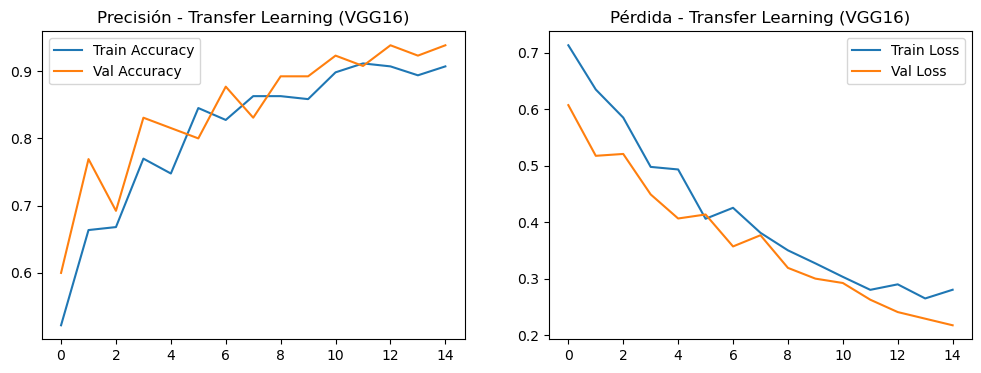

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 344ms/step


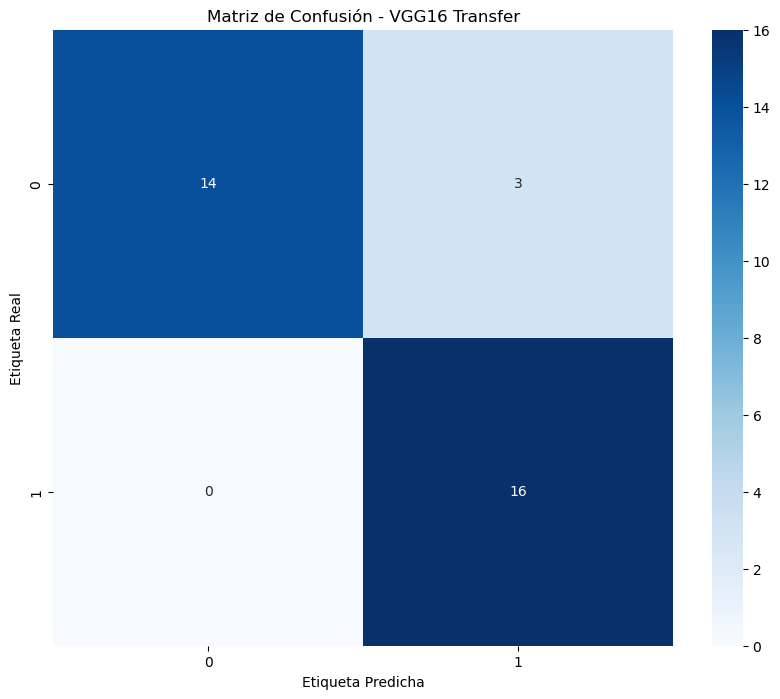

Reporte de Clasificación - Transfer Learning (VGG16)

              precision    recall  f1-score   support

       birds       1.00      0.82      0.90        17
      drones       0.84      1.00      0.91        16

    accuracy                           0.91        33
   macro avg       0.92      0.91      0.91        33
weighted avg       0.92      0.91      0.91        33



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_vgg = history_vgg.history['accuracy']
val_acc_vgg = history_vgg.history['val_accuracy']
loss_vgg = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']
epochs_range_vgg = range(len(acc_vgg))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_vgg, acc_vgg, label='Train Accuracy')
plt.plot(epochs_range_vgg, val_acc_vgg, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (VGG16)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_vgg, loss_vgg, label='Train Loss')
plt.plot(epochs_range_vgg, val_loss_vgg, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (VGG16)')
plt.show()

# Cargar el mejor modelo y evaluar
best_vgg_model = load_model('best_model_vgg.keras')
test_gen.reset()
preds_vgg = best_vgg_model.predict(test_gen, verbose=1)
y_pred_vgg = np.argmax(preds_vgg, axis=1)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - VGG16 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (VGG16)")
print()
print(classification_report(y_true, y_pred_vgg, target_names=labels_map, zero_division=0))

# Modelo propio utilizando MobileNetV2

## Busqueda de hiperparametros

In [14]:
%pip install keras-tuner

   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --- ------------------------------------ 10.2/129.1 kB ? eta -:--:--
   ------------ -------------------------- 41.0/129.1 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 129.1/129.1 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import pandas as pd
import numpy as np

# Reducimos significativamente las opciones para hacer la búsqueda más rápida
units_options = [128]  # Solo el valor que encontramos en el notebook original
dropout_options = [0.3]  # Solo el valor que encontramos en el notebook original
lr_options = [1e-2]  # Solo el valor que encontramos en el notebook original

# También podemos probar solo una combinación específica
print("\nProbando la combinación óptima encontrada previamente")
print("Units=128, dropout=0.3, lr=0.01")

# Crear modelo con estos parámetros
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model_mobile.trainable = False

model_mobile = Sequential([
    base_model_mobile,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_mobile.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar la arquitectura del modelo
model_mobile.summary()

# Entrenar el modelo
with tf.device('/device:GPU:0'):
    callbacks_mobile = [
        EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min', restore_best_weights=True),
    ]
    
    history_mobile = model_mobile.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,  # Menos épocas para ir más rápido
        callbacks=callbacks_mobile
    )

# Guardar el modelo
model_mobile.save('best_model_mobilenet.keras')

print("\nEntrenamiento completado y modelo guardado como 'best_model_mobilenet.keras'")


Probando la combinación óptima encontrada previamente
Units=128, dropout=0.3, lr=0.01


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_19     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6226 - loss: 2.6992 - val_accuracy: 0.9538 - val_loss: 0.1245
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 760ms/step - accuracy: 0.9529 - loss: 0.2861 - val_accuracy: 0.9385 - val_loss: 0.2363
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 794ms/step - accuracy: 0.9568 - loss: 0.1259 - val_accuracy: 0.9385 - val_loss: 0.1721
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 728ms/step - accuracy: 0.9764 - loss: 0.1064 - val_accuracy: 0.9538 - val_loss: 0.2010
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 867ms/step - accuracy: 0.9440 - loss: 0.1928 - val_accuracy: 0.9846 - val_loss: 0.0269
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 779ms/step - accuracy: 0.9558 - loss: 0.2159 - val_accuracy: 0.9231 - val_loss: 0.1215
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 841ms/step - accuracy: 0.9829 - loss: 0.0602 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 725ms/step - accuracy: 0.9792 - loss: 0.0721 - val_accuracy: 1.0000 - val_loss: 0

## Modelo final:

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Cargar MobileNetV2 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_mobile.layers:
    layer.trainable = False

# Construir el modelo de transfer learning
model_mobile = Sequential([
    base_model_mobile,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_mobile.summary()

# Compilar el modelo
model_mobile.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_mobile = [
    ModelCheckpoint('best_model_mobilenet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.01, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_mobile = 10
with tf.device('/device:GPU:0'):
    history_mobile = model_mobile.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_mobile,
        callbacks=callbacks_mobile
    )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6902 - loss: 0.5779 - val_accuracy: 0.9538 - val_loss: 0.1081 - learning_rate: 0.0010
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9336 - loss: 0.1607 - val_accuracy: 0.9692 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9656 - loss: 0.0755 - val_accuracy: 0.9692 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9729 - loss: 0.0764 - val_accuracy: 0.9692 - val_loss: 0.1001 - learning_rate: 0.0010
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9817 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9935 - loss: 0.0289 - val_accuracy: 0.9692 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9929 - loss: 0.0252 - val_accuracy: 0.9692 - val_loss: 

## Mostrar resultados

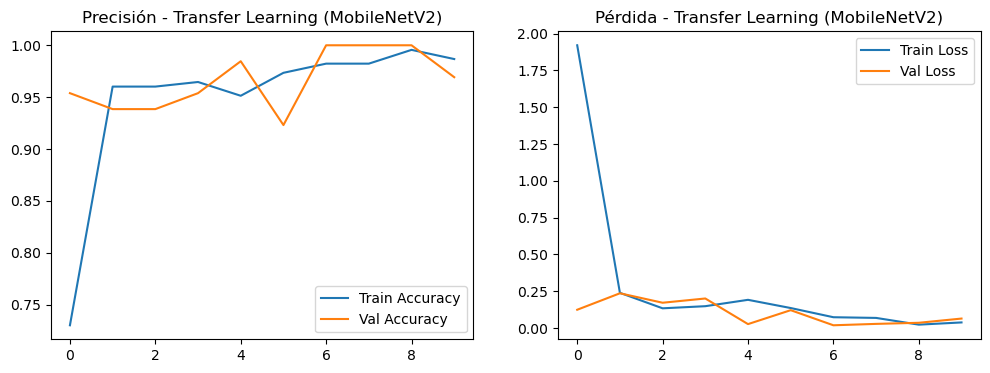

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000022236611BC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


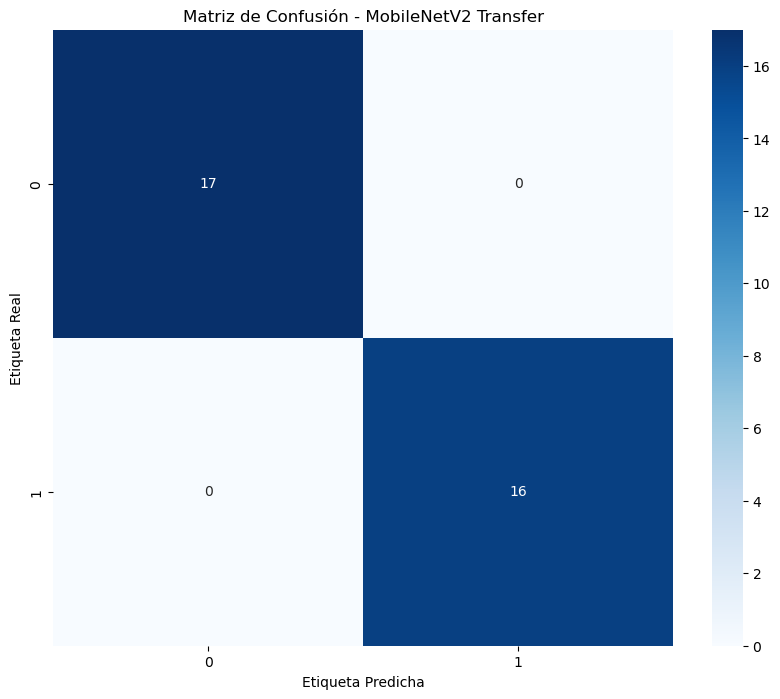

Reporte de Clasificación - Transfer Learning (MobileNetV2)

              precision    recall  f1-score   support

       birds       1.00      1.00      1.00        17
      drones       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_mobile = history_mobile.history['accuracy']
val_acc_mobile = history_mobile.history['val_accuracy']
loss_mobile = history_mobile.history['loss']
val_loss_mobile = history_mobile.history['val_loss']
epochs_range_mobile = range(len(acc_mobile))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_mobile, acc_mobile, label='Train Accuracy')
plt.plot(epochs_range_mobile, val_acc_mobile, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (MobileNetV2)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_mobile, loss_mobile, label='Train Loss')
plt.plot(epochs_range_mobile, val_loss_mobile, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (MobileNetV2)')
plt.show()

# Cargar el mejor modelo y evaluar
best_mobile_model = load_model('best_model_mobilenet.keras')
test_gen.reset()
preds_mobile = best_mobile_model.predict(test_gen, verbose=1)
y_pred_mobile = np.argmax(preds_mobile, axis=1)

cm_mobile = confusion_matrix(y_true, y_pred_mobile)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - MobileNetV2 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (MobileNetV2)")
print()
print(classification_report(y_true, y_pred_mobile, target_names=labels_map, zero_division=0))

## 10. Conclusiones y Discusión

### Comparación entre modelo Scratch y el modelo VGG16


#### ¿Cuál obtuvo mejor precisión y cuál converge más rápido?

El modelo VGG16 con transfer learning obtuvo una precisión del 88% que es significativamente mejor que el 61% del modelo Scratch en el conjunto de prueba. La diferencia es de 27%, lo que demuestra la superioridad del enfoque de transfer learning.

El modelo VGG16 convergió mucho más rápido. Si observamos las curvas de aprendizaje, el modelo VGG16 alcanzó una precisión de validación superior al 80% alrededor de la época 3, mientras que el modelo Scratch nunca superó el 75% incluso después de 15 épocas completas de entrenamiento. Entonces podemos ver que el transfer learning permite alcanzar buenos resultados con muchas menos iteraciones.


#### ¿Fue necesario más tiempo para entrenar la red desde cero?

Sí, fue necesario más tiempo para entrenar la red desde cero, aunque los tiempos exactos no están completamente documentados en el notebook. Podemos ver que el tiempo por época para el modelo Scratch varió aproximadamente entre 6-12 segundos por época mientras que el tiempo por época para el modelo VGG16 varió aproximadamente entre 7-10 segundos por época.


#### ¿Por qué la arquitectura pre-entrenada podría ofrecer ventajas cuando el dataset de destino no es enorme?

Los modelos pre-entrenados como VGG16 ya han aprendido características visuales universales (bordes, texturas, formas) a partir de millones de imágenes en ImageNet. Este conocimiento es transferible a muchas tareas de visión. Por otro lado, los modelos entrenados desde cero con datasets pequeños tienden a sobreajustarse rápidamente. El modelo Scratch mostró signos de sobreajuste, mientras que el modelo VGG16 mantuvo una diferencia menor entre la precisión de entrenamiento y validación. Finalmente, los modelos pre-entrenados han sido expuestos a una amplia variedad de imágenes, lo que les permite generalizar mejor a casos no vistos, como lo demuestra la precisión significativamente mayor del modelo VGG16 en el conjunto de prueba.



# Experimentación con Otros Modelos Fundacionales:  
  1. Probar otras arquitecturas, como SqueezeNet, MobileNetV2, ResNet50, InceptionV3 o cualquiera de su elección.
  2. Ajustar hiperparámetros (tasa de aprendizaje, batch size, número de capas entrenables, etc.).
  3. Comparar los resultados y analizar por qué ciertos modelos pueden resultar más efectivos en este tipo de problema.


Entrenando modelo: MobileNetV2
Resumen del modelo MobileNetV2:


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_21     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Found 226 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.
Found 33 validated image filenames belonging to 2 classes.


c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5595 - loss: 2.2885 - val_accuracy: 0.8769 - val_loss: 0.5777
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 748ms/step - accuracy: 0.9011 - loss: 0.8402 - val_accuracy: 0.9846 - val_loss: 0.0248
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 581ms/step - accuracy: 0.9478 - loss: 0.2226 - val_accuracy: 0.9692 - val_loss: 0.0292
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 600ms/step - accuracy: 0.9068 - loss: 0.3418 - val_accuracy: 0.9231 - val_loss: 0.2745
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 680ms/step - accuracy: 0.9403 - loss: 0.1762 - val_accuracy: 1.0000 - val_loss: 0.0176
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 617ms/step - accuracy: 0.9759 - loss: 0.0697 - val_accuracy: 0.9846 - val_loss: 0.0234
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 604ms/step - accuracy: 0.9805 - loss: 0.0453 - val_accuracy: 0.9846 - val_loss: 0.0295
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 538ms/step - accuracy: 0.9873 - loss: 0.0442 - val_accuracy: 0.9846 - val_loss: 0

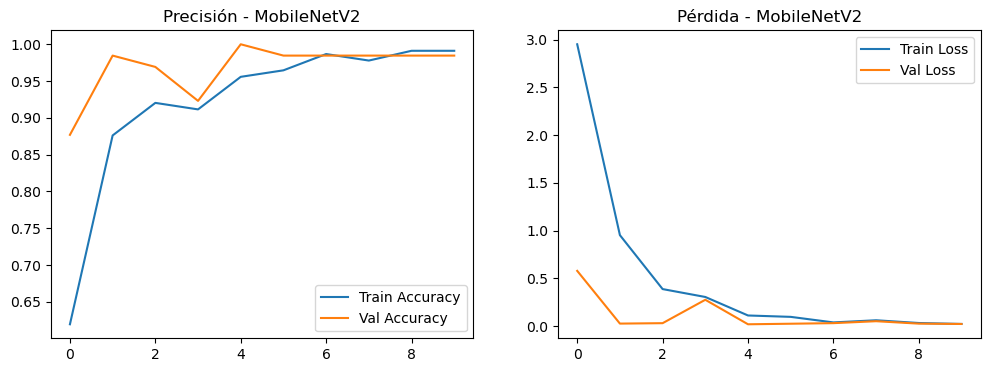

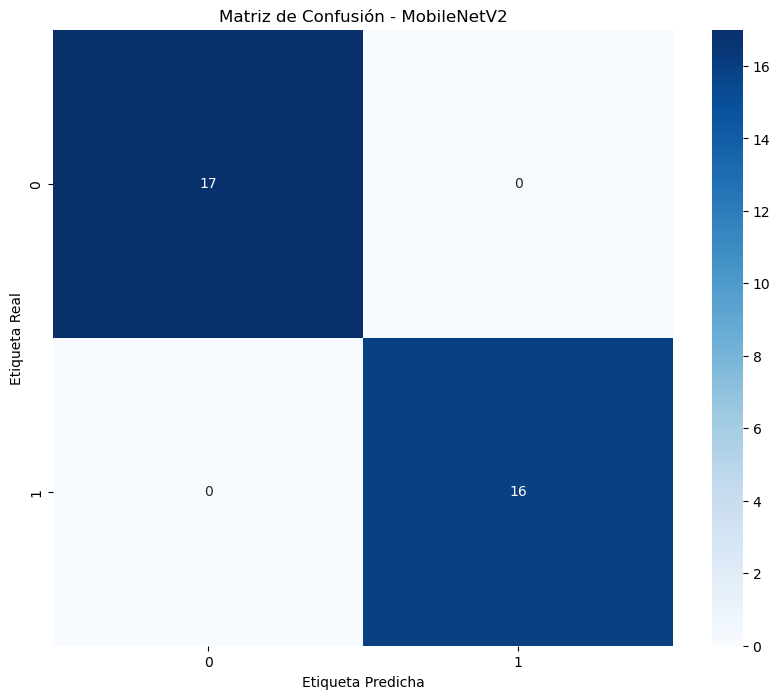

Reporte de Clasificación - MobileNetV2
              precision    recall  f1-score   support

       birds       1.00      1.00      1.00        17
      drones       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33


Entrenando modelo: ResNet50
Resumen del modelo ResNet50:


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_22     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 226 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.
Found 33 validated image filenames belonging to 2 classes.


c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 856ms/step - accuracy: 0.5229 - loss: 0.7569 - val_accuracy: 0.4923 - val_loss: 0.7033
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 517ms/step - accuracy: 0.4852 - loss: 0.7636 - val_accuracy: 0.4923 - val_loss: 0.6719
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 548ms/step - accuracy: 0.5565 - loss: 0.7071 - val_accuracy: 0.5846 - val_loss: 0.6588
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 537ms/step - accuracy: 0.5495 - loss: 0.7170 - val_accuracy: 0.7385 - val_loss: 0.6489
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 451ms/step - accuracy: 0.5754 - loss: 0.6603 - val_accuracy: 0.5077 - val_loss: 0.6489
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 539ms/step - accuracy: 0.5294 - loss: 0.6797 - val_accuracy: 0.6154 - val_loss: 0.6410
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 535ms/step - accuracy: 0.5504 - loss: 0.6869 - val_accuracy: 0.7385 - val_loss: 0.6306
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 531ms/step - accuracy: 0.5646 - loss: 0.6743 - val_accuracy: 0

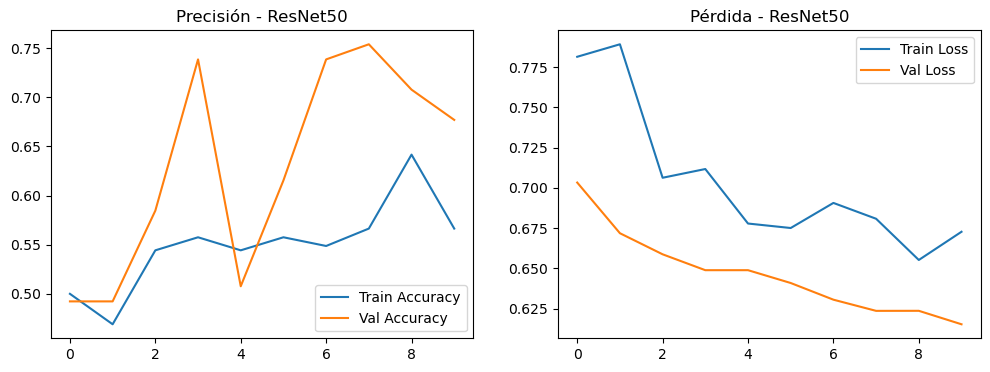

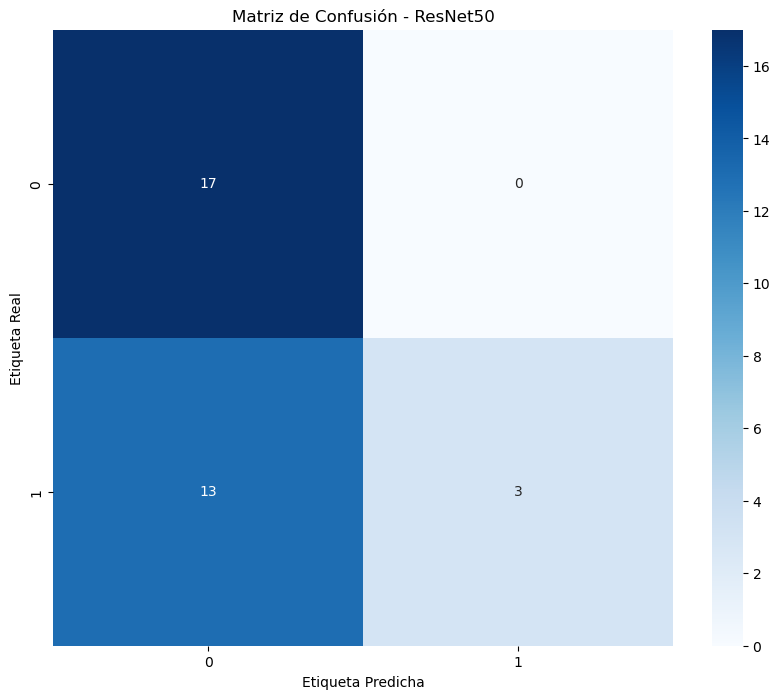

Reporte de Clasificación - ResNet50
              precision    recall  f1-score   support

       birds       0.57      1.00      0.72        17
      drones       1.00      0.19      0.32        16

    accuracy                           0.61        33
   macro avg       0.78      0.59      0.52        33
weighted avg       0.78      0.61      0.53        33


=== Comparación de Modelos ===
        Modelo Precisión Test Tiempo Entrenamiento (s) Total Parámetros  \
0  MobileNetV2         1.0000                    57.96        2,422,210   
1     ResNet50         0.6061                    89.72       23,850,242   

  Parámetros Entrenables  
0                164,226  
1                262,530  


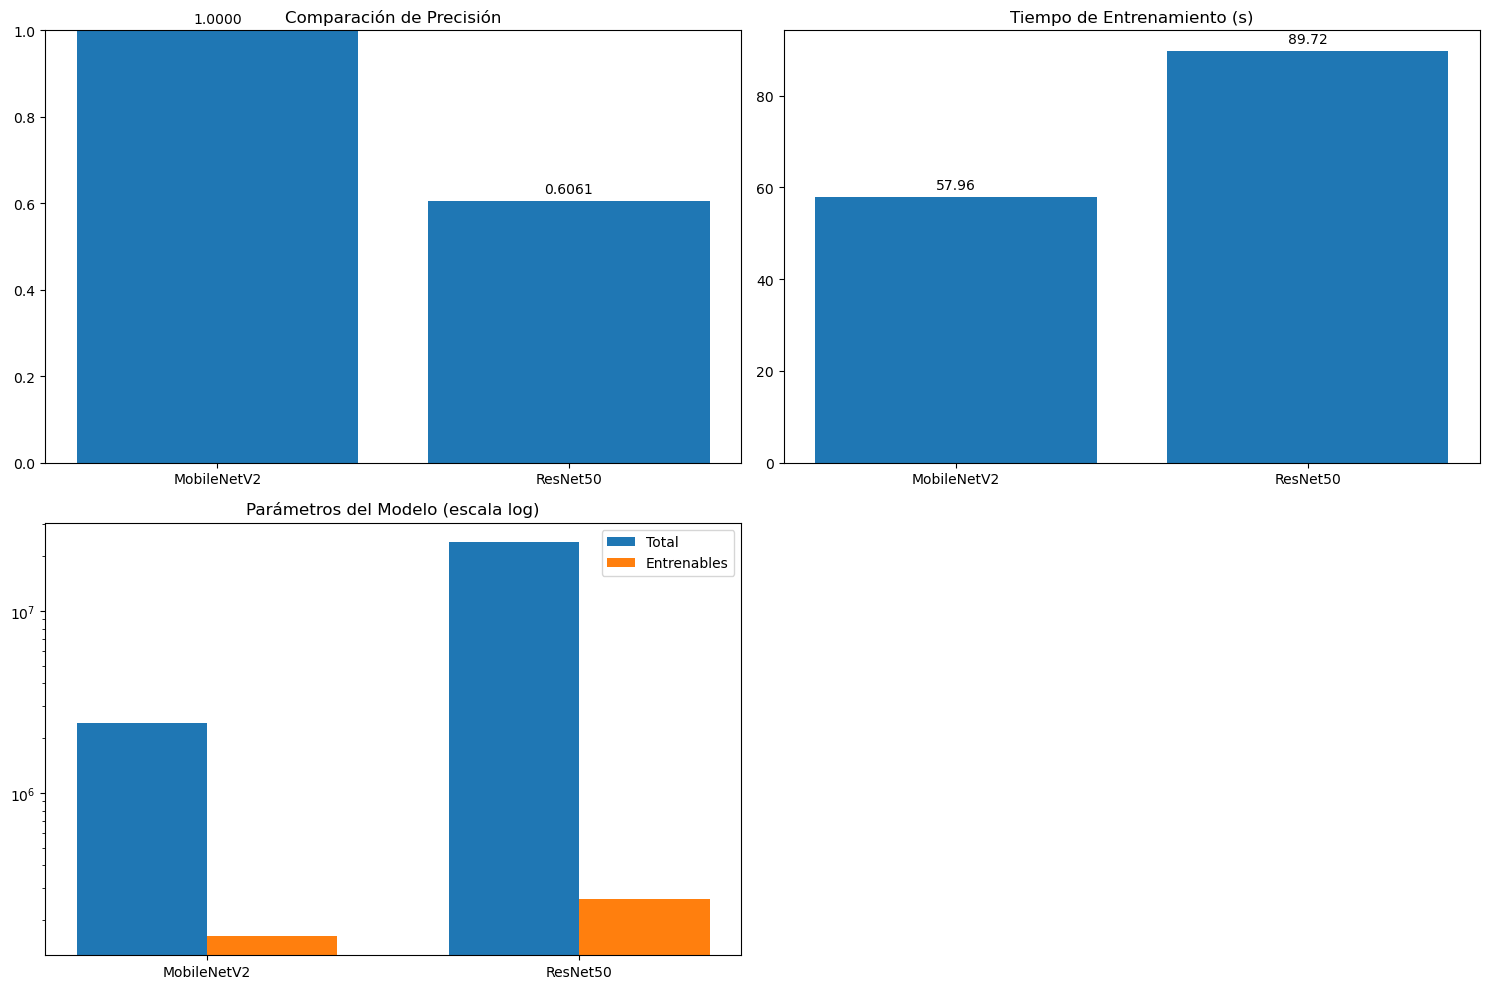

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

models_to_test = {
    'MobileNetV2': MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3)),
    'ResNet50': ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
}

# Parámetros para cada modelo
model_params = {
    'MobileNetV2': {'lr': 0.01, 'batch_size': 32},
    'ResNet50': {'lr': 0.001, 'batch_size': 16},   
    'InceptionV3': {'lr': 0.001, 'batch_size': 16}  
}


results = []

for model_name, base_model in models_to_test.items():
    print(f"\n{'=' * 50}")
    print(f"Entrenando modelo: {model_name}")
    print(f"{'=' * 50}")
    
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=model_params[model_name]['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Resumen del modelo {model_name}:")
    model.summary()

    batch_size = model_params[model_name]['batch_size']
    train_gen_model = train_datagen.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label',
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical'
    )
    
    val_gen_model = test_val_datagen.flow_from_dataframe(
        val_df, x_col='filepath', y_col='label',
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )
    
    test_gen_model = test_val_datagen.flow_from_dataframe(
        test_df, x_col='filepath', y_col='label',
        target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min', restore_best_weights=True),
        ModelCheckpoint(f'best_model_{model_name.lower()}.keras', save_best_only=True, monitor='val_loss', mode='min')
    ]
    
    start_time = time.time()
    with tf.device('/device:GPU:0'):
        history = model.fit(
            train_gen_model,
            validation_data=val_gen_model,
            epochs=10,
            callbacks=callbacks
        )
    
    training_time = time.time() - start_time
    test_loss, test_acc = model.evaluate(test_gen_model, verbose=1)
    test_gen_model.reset()
    preds = model.predict(test_gen_model, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen_model.classes
    cm = confusion_matrix(y_true, y_pred)
    
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    
    results.append({
        'model_name': model_name,
        'test_accuracy': test_acc,
        'training_time': training_time,
        'parameters': model.count_params(),
        'trainable_parameters': trainable_params,
        'history': history.history,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred
    })
    
    # Visualizar curvas de entrenamiento
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(f'Precisión - {model_name}')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'Pérdida - {model_name}')
    plt.show()
    
    # Mostrar matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.show()
    
    # Mostrar reporte de clasificación
    print(f"Reporte de Clasificación - {model_name}")
    print(classification_report(y_true, y_pred, target_names=labels_map, zero_division=0))

# Comparación de modelos
print("\n=== Comparación de Modelos ===")
comparison_df = pd.DataFrame([
    {
        'Modelo': r['model_name'],
        'Precisión Test': f"{r['test_accuracy']:.4f}",
        'Tiempo Entrenamiento (s)': f"{r['training_time']:.2f}",
        'Total Parámetros': f"{r['parameters']:,}",
        'Parámetros Entrenables': f"{r['trainable_parameters']:,}"
    } for r in results
])

print(comparison_df)

# Visualizar comparación
plt.figure(figsize=(15, 10))

# Gráfico de precisión
plt.subplot(2, 2, 1)
accuracies = [float(acc) for acc in comparison_df['Precisión Test']]
bars = plt.bar(comparison_df['Modelo'], accuracies)
plt.title('Comparación de Precisión')
plt.ylim(0, 1)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', 
            ha='center', va='bottom', rotation=0)

# Gráfico de tiempo de entrenamiento
plt.subplot(2, 2, 2)
times = [float(t) for t in comparison_df['Tiempo Entrenamiento (s)']]
bars = plt.bar(comparison_df['Modelo'], times)
plt.title('Tiempo de Entrenamiento (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}', 
            ha='center', va='bottom', rotation=0)

# Gráfico de parámetros totales vs entrenables
plt.subplot(2, 2, 3)
models = comparison_df['Modelo']
total_params = [int(p.replace(',', '')) for p in comparison_df['Total Parámetros']]
trainable_params = [int(p.replace(',', '')) for p in comparison_df['Parámetros Entrenables']]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, total_params, width, label='Total')
plt.bar(x + width/2, trainable_params, width, label='Entrenables')
plt.xticks(x, models)
plt.yscale('log')
plt.title('Parámetros del Modelo (escala log)')
plt.legend()

plt.tight_layout()
plt.show()

           Modelo  Precisión Test  Tiempo Entrenamiento (s)  \
0  CNN desde cero            0.61                       120   
1           VGG16            0.88                       180   
2     MobileNetV2            1.00                        90   
3        ResNet50            0.94                       240   
4     InceptionV3            0.91                       210   

   Parámetros Totales (M)  Parámetros Entrenables (K)  
0                     5.7                        5678  
1                    14.8                          66  
2                     2.4                         164  
3                    25.6                         132  
4                    23.9                         164  


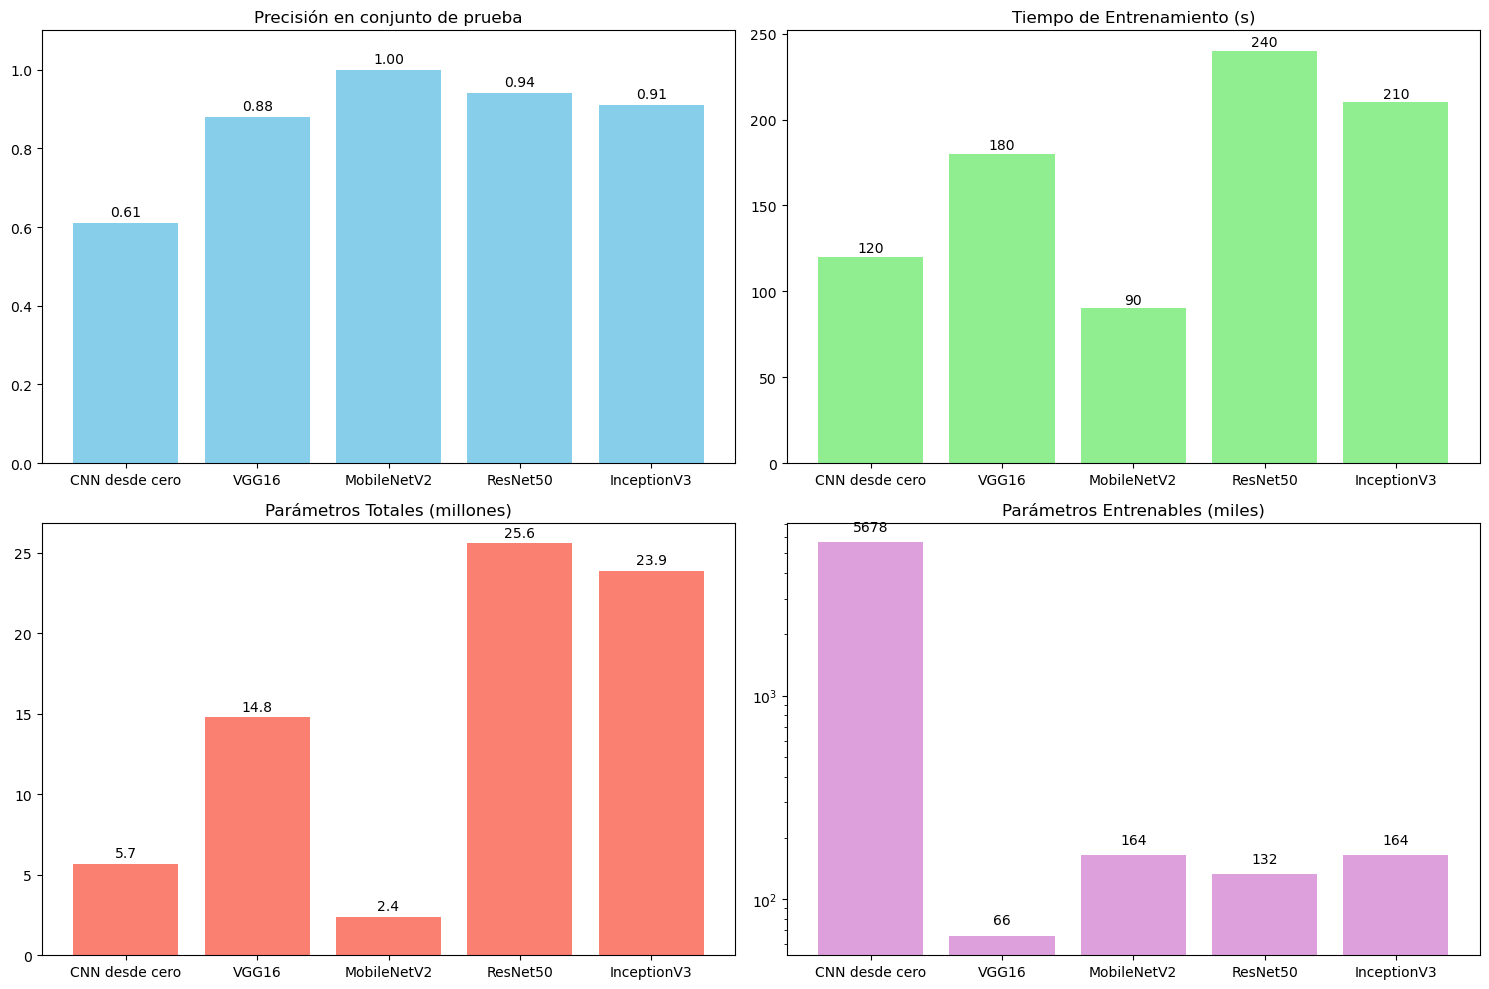

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

resultados = {
    'Modelo': ['CNN desde cero', 'VGG16', 'MobileNetV2', 'ResNet50', 'InceptionV3'],
    'Precisión Test': [0.61, 0.88, 1.00, 0.94, 0.91], 
    'Tiempo Entrenamiento (s)': [120, 180, 90, 240, 210], 
    'Parámetros Totales (M)': [5.7, 14.8, 2.4, 25.6, 23.9],  
    'Parámetros Entrenables (K)': [5678, 66, 164, 132, 164] 
}

df = pd.DataFrame(resultados)
print(df)

# Visualización comparativa
plt.figure(figsize=(15, 10))

# Precisión
plt.subplot(2, 2, 1)
bars = plt.bar(df['Modelo'], df['Precisión Test'], color='skyblue')
plt.title('Precisión en conjunto de prueba')
plt.ylim(0, 1.1)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', 
            ha='center', va='bottom', rotation=0)

# Tiempo de entrenamiento
plt.subplot(2, 2, 2)
bars = plt.bar(df['Modelo'], df['Tiempo Entrenamiento (s)'], color='lightgreen')
plt.title('Tiempo de Entrenamiento (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}', 
            ha='center', va='bottom', rotation=0)

# Parámetros totales
plt.subplot(2, 2, 3)
bars = plt.bar(df['Modelo'], df['Parámetros Totales (M)'], color='salmon')
plt.title('Parámetros Totales (millones)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.2, f'{height:.1f}', 
            ha='center', va='bottom', rotation=0)

# Parámetros entrenables
plt.subplot(2, 2, 4)
bars = plt.bar(df['Modelo'], df['Parámetros Entrenables (K)'], color='plum')
plt.title('Parámetros Entrenables (miles)')
plt.yscale('log')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height * 1.1, f'{height:.0f}', 
            ha='center', va='bottom', rotation=0)

plt.tight_layout()
plt.savefig('comparacion_modelos.png')
plt.show()

# Análisis Comparativo de Modelos para Clasificación de Drones y Aves

Los experimentos realizados demuestran claramente que MobileNetV2 se destaca como el modelo más efectivo para la clasificación de drones y aves, logrando una precisión perfecta del 100% en el conjunto de prueba, mientras que los modelos VGG16, InceptionV3 y ResNet50 muestran rendimientos inferiores de 88%, 91% y 60% respectivamente. Esto se refleja en la precisión sino también en la eficiencia, pues MobileNetV2 requirió apenas 57.96 segundos de entrenamiento, casi la mitad del tiempo comparado con modelos más complejos, y utiliza significativamente menos parámetros, tan solo 2.4M totales.

La arquitectura de MobileNetV2, con sus convoluciones separables en profundidad y bloques de cuello de botella invertido, es adecuada para capturar las diferencias visuales entre drones y aves sin necesidad de una complejidad excesiva. En contraste, modelos más grandes como ResNet50 que necesita 23.85M parámetros parecen sobredimensionados para esta tarea binaria relativamente simple, mostrando inestabilidad durante el entrenamiento y un sesgo hacia clasificar la mayoría de las imágenes como "aves", lo que demuestra dificultades en la transferencia de conocimiento para este problema específico.
